In [ ]:
# Define search terms
search_terms <- c(
  "TFAM", "VDAC1", "COX1", "COX2", "MT-CO1", "MT-ATP6", "SDHA", "ATP5A",
  "UQCRC2", "NDUFB8", "PTPRC", "CD45", "HK2", "PKM1", "PKM2", "MYC",
  "HIF1A", "NRF2", "NFE2L2", "PARP1", "GLDC", "ESRP1",
  "MT-ND1", "MT-ND2", "MT-ND3", "MT-ND4", "MT-ND5", "MT-ND6",
  "NDUFS1", "NDUFS2", "NDUFS3", "NDUFS4", "NDUFS5", "NDUFS6", "NDUFS7", "NDUFS8",
  "NDUFV1", "NDUFV2", "MT-CYB", "BCS1L", "SDHB", "SDHC", "SDHD",
  "SLC25A4", "SLC25A5", "UCP1", "UCP2", "PGC1A", "POLG", "POLG2",
  "TWNK", "C10orf2", "TK2", "DGUOK", "SUCLA2", "SUCLG1", "RRM2B",
  "TYMP", "MPV17", "OPA1", "MFN1", "MFN2", "DRP1", "DNM1L", "FIS1",
  "PINK1", "PARK2", "NIX", "ULK1", "AMBRA1", "SIRT1", "SIRT3",
  "SOD2", "CAT", "GPX1", "MT-TL1", "MT-TK", "MT-TI", "MT-TW", "MT-TG",
  "ITGA2", "ITGA5", "ITGB1", "ITGB3"
)

# Load data
df <- read.csv("Masterfile/CrossPlatfromNorm.csv", row.names = 1, check.names = FALSE)

# Function to check if gene name starts with any search term
starts_with_search_term <- function(gene) {
  any(sapply(search_terms, function(term) startsWith(gene, term)))
}

# Filter genes
filtered_df <- df[sapply(rownames(df), starts_with_search_term), ]

# Write filtered table to new file
write.csv(filtered_df, "Masterfile/Mitochondria/mito_gene_expression.csv")


In [9]:
df <- read.csv("Masterfile/Mitochondria/mito_gene_expression.csv", row.names = 1, check.names = FALSE)
df[is.na(df)] <- 0
write.csv(df, "Masterfile/Mitochondria/mito_gene_expression.csv")


Performing PCA
Read the 69 x 50 data matrix successfully!
OpenMP is working. 1 threads.
Using no_dims = 2, perplexity = 22.000000, and theta = 0.500000
Computing input similarities...
Building tree...
Done in 0.01 seconds (sparsity = 0.984247)!
Learning embedding...
Iteration 50: error is 53.799119 (50 iterations in 0.01 seconds)
Iteration 100: error is 53.972533 (50 iterations in 0.01 seconds)
Iteration 150: error is 56.228694 (50 iterations in 0.00 seconds)
Iteration 200: error is 54.000522 (50 iterations in 0.01 seconds)
Iteration 250: error is 55.850538 (50 iterations in 0.01 seconds)
Iteration 300: error is 1.434787 (50 iterations in 0.00 seconds)
Iteration 350: error is 1.134904 (50 iterations in 0.00 seconds)
Iteration 400: error is 0.781375 (50 iterations in 0.00 seconds)
Iteration 450: error is 0.521125 (50 iterations in 0.00 seconds)
Iteration 500: error is 0.361070 (50 iterations in 0.00 seconds)
Iteration 550: error is 0.262230 (50 iterations in 0.01 seconds)
Iteration 600:

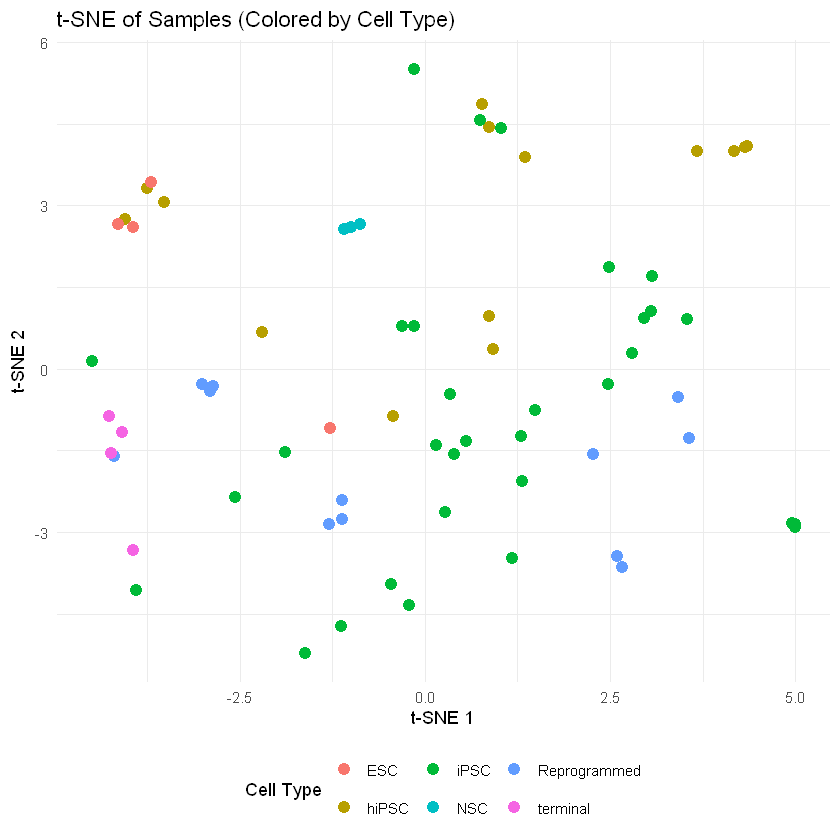

In [ ]:
plot_sample_tsne <- function(expr_file, gene_col = "GENE_ID", out_prefix = "tSNE_plot") {
  library(readr)
  library(dplyr)
  library(ggplot2)
  library(tidyr)
  library(Rtsne)
  
  # 1. Load data
  df <- read_csv(expr_file, show_col_types = FALSE)
  
  # 2. Extract gene names and sample expression data
  gene_names <- df[[gene_col]]
  df_samples <- df %>% select(-all_of(gene_col))
  
  # 3. Convert to matrix and set gene names as rownames
  expr_mat <- as.matrix(df_samples)
  rownames(expr_mat) <- gene_names
  
  # 4. Transpose: samples as rows, genes as columns
  expr_mat_t <- t(expr_mat)
  
  # 5. Remove samples with all NA or zero variance
  expr_mat_t <- expr_mat_t[rowSums(is.na(expr_mat_t)) < ncol(expr_mat_t), , drop = FALSE]
  expr_mat_t <- expr_mat_t[apply(expr_mat_t, 1, function(x) var(x, na.rm = TRUE) > 0), , drop = FALSE]
  
  # 6. Impute missing values (gene-wise mean)
  for(j in seq_len(ncol(expr_mat_t))) {
    nas <- is.na(expr_mat_t[, j])
    if(any(nas)) expr_mat_t[nas, j] <- mean(expr_mat_t[!nas, j], na.rm = TRUE)
  }
  
  # 7. Scale genes (columns)
  expr_scaled <- scale(expr_mat_t)
  
  # 8. Prepare sample metadata
  sample_names <- rownames(expr_scaled)
  parse_sample <- function(x) {
    parts <- unlist(strsplit(x, "_"))
    dataset <- if(length(parts) > 0) tail(parts, 1) else NA
    celltype <- if(length(parts) > 1) parts[length(parts) - 1] else NA
    data.frame(Sample = x, dataset = dataset, celltype = celltype, stringsAsFactors = FALSE)
  }
  sample_info <- bind_rows(lapply(sample_names, parse_sample))
  
  # 9. Run t-SNE
  set.seed(42)
  perplexity_value <- min(30, floor((nrow(expr_scaled) - 1) / 3))
  tsne_result <- Rtsne(expr_scaled, dims = 2, perplexity = perplexity_value, verbose = TRUE, max_iter = 1000)
  
  tsne_df <- as.data.frame(tsne_result$Y)
  names(tsne_df) <- c("tSNE1", "tSNE2")
  tsne_df$Sample <- rownames(expr_scaled)
  tsne_df <- left_join(tsne_df, sample_info, by = "Sample")
  
  # 11. Plot by cell type
  p2 <- ggplot(tsne_df, aes(x = tSNE1, y = tSNE2, color = celltype)) +
    geom_point(size = 3) +
    theme_minimal() +
    labs(title = "t-SNE of Samples (Colored by Cell Type)", x = "t-SNE 1", y = "t-SNE 2", color = "Cell Type") +
    theme(legend.position = "bottom")
  
  # 12. Save and print plots
  ggsave(paste0(out_prefix, "_by_celltype.png"), plot = p2, width = 8, height = 6, dpi = 300)
  print(p2)
}

plot_sample_tsne("Masterfile/Mitochondria/mito_gene_expression.csv")

Performing PCA
Read the 69 x 50 data matrix successfully!
OpenMP is working. 1 threads.
Using no_dims = 2, perplexity = 22.000000, and theta = 0.500000
Computing input similarities...
Building tree...
Done in 0.01 seconds (sparsity = 0.984247)!
Learning embedding...
Iteration 50: error is 53.799119 (50 iterations in 0.01 seconds)
Iteration 100: error is 53.972533 (50 iterations in 0.01 seconds)
Iteration 150: error is 56.228694 (50 iterations in 0.01 seconds)
Iteration 200: error is 54.000522 (50 iterations in 0.01 seconds)
Iteration 250: error is 55.850538 (50 iterations in 0.01 seconds)
Iteration 300: error is 1.434787 (50 iterations in 0.00 seconds)
Iteration 350: error is 1.134904 (50 iterations in 0.01 seconds)
Iteration 400: error is 0.781375 (50 iterations in 0.01 seconds)
Iteration 450: error is 0.521125 (50 iterations in 0.00 seconds)
Iteration 500: error is 0.361070 (50 iterations in 0.00 seconds)
Iteration 550: error is 0.262230 (50 iterations in 0.01 seconds)
Iteration 600:

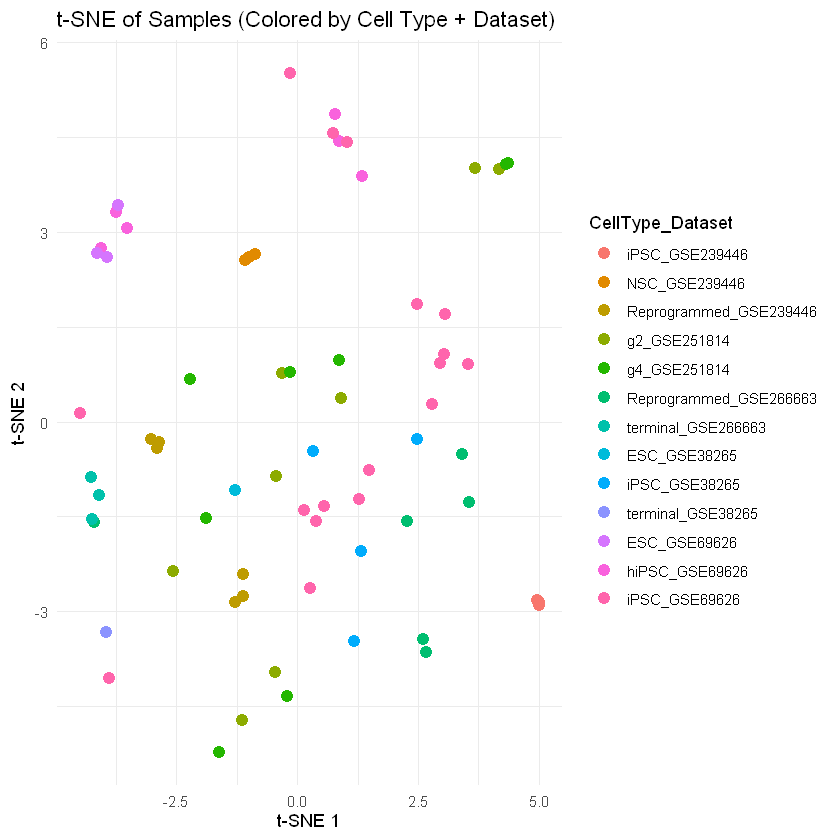

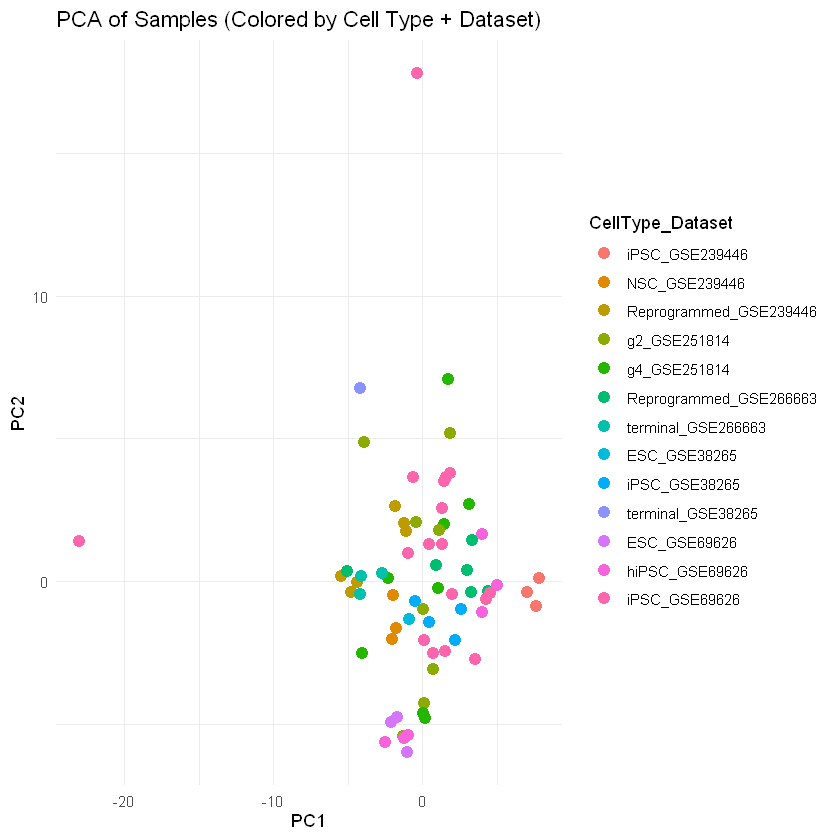

In [ ]:
plot_sample_tsne_pca <- function(expr_file, gene_col = "GENE_ID", out_prefix = "sample_plot") {
  library(readr)
  library(dplyr)
  library(ggplot2)
  library(tidyr)
  library(Rtsne)
  
  # 1. Load data
  df <- read_csv(expr_file, show_col_types = FALSE)
  
  # 2. Extract gene names and sample expression data
  gene_names <- df[[gene_col]]
  df_samples <- df %>% select(-all_of(gene_col))
  
  # 3. Convert to matrix and set gene names as rownames
  expr_mat <- as.matrix(df_samples)
  rownames(expr_mat) <- gene_names
  
  # 4. Transpose: samples as rows, genes as columns
  expr_mat_t <- t(expr_mat)
  
  # 5. Remove samples with all NA or zero variance
  expr_mat_t <- expr_mat_t[rowSums(is.na(expr_mat_t)) < ncol(expr_mat_t), , drop = FALSE]
  expr_mat_t <- expr_mat_t[apply(expr_mat_t, 1, function(x) var(x, na.rm = TRUE) > 0), , drop = FALSE]
  
  # 6. Impute missing values (gene-wise mean)
  for (j in seq_len(ncol(expr_mat_t))) {
    nas <- is.na(expr_mat_t[, j])
    if (any(nas)) expr_mat_t[nas, j] <- mean(expr_mat_t[!nas, j], na.rm = TRUE)
  }
  
  # 7. Scale genes (columns)
  expr_scaled <- scale(expr_mat_t)
  
  # 8. Prepare sample metadata (parse cell type and dataset)
  sample_names <- rownames(expr_scaled)
  parse_sample <- function(x) {
    parts <- unlist(strsplit(x, "_"))
    n <- length(parts)
    dataset <- parts[n]
    celltype_candidates <- c("NSC", "iPSC", "ESC", "Reprogrammed", 
                             "hiPSC", "terminal", "CTL", "DOX", "g2", "g4")
    celltype <- parts[which(parts %in% celltype_candidates)][1]
    if (is.na(celltype) || length(celltype) == 0) celltype <- parts[n - 1]
    data.frame(Sample = x, dataset = dataset, celltype = celltype, stringsAsFactors = FALSE)
  }
  sample_info <- bind_rows(lapply(sample_names, parse_sample))
  
  # 9. Create combined group for coloring
  sample_info$group <- interaction(sample_info$celltype, sample_info$dataset, sep = "_")
  
  # 10. Run t-SNE
  set.seed(42)
  perplexity_value <- min(30, floor((nrow(expr_scaled) - 1) / 3))
  tsne_result <- Rtsne(expr_scaled, dims = 2, perplexity = perplexity_value,
                       verbose = TRUE, max_iter = 1000)
  
  tsne_df <- as.data.frame(tsne_result$Y)
  names(tsne_df) <- c("tSNE1", "tSNE2")
  tsne_df$Sample <- rownames(expr_scaled)
  tsne_df <- left_join(tsne_df, sample_info, by = "Sample")
  
  # 11. Plot t-SNE colored by combined cell type and dataset
  p_tsne <- ggplot(tsne_df, aes(x = tSNE1, y = tSNE2, color = group)) +
    geom_point(size = 3) +
    theme_minimal() +
    labs(title = "t-SNE of Samples (Colored by Cell Type + Dataset)",
         x = "t-SNE 1", y = "t-SNE 2", color = "CellType_Dataset") +
    theme(legend.position = "right")
  
  ggsave(paste0(out_prefix, "_tSNE_by_celltype_dataset.png"), plot = p_tsne, width = 8, height = 6, dpi = 300)
  print(p_tsne)
  
  # 12. Run PCA
  pca_result <- prcomp(expr_scaled, center = TRUE, scale. = TRUE)
  pca_df <- as.data.frame(pca_result$x[, 1:2])
  names(pca_df) <- c("PC1", "PC2")
  pca_df$Sample <- rownames(expr_scaled)
  pca_df <- left_join(pca_df, sample_info, by = "Sample")
  
  # 13. Plot PCA colored by combined cell type and dataset
  p_pca <- ggplot(pca_df, aes(x = PC1, y = PC2, color = group)) +
    geom_point(size = 3) +
    theme_minimal() +
    labs(title = "PCA of Samples (Colored by Cell Type + Dataset)",
         x = "PC1", y = "PC2", color = "CellType_Dataset") +
    theme(legend.position = "right")
  
  ggsave(paste0(out_prefix, "_PCA_by_celltype_dataset.png"), plot = p_pca, width = 8, height = 6, dpi = 300)
  print(p_pca)
}
plot_sample_tsne_pca("Masterfile/Mitochondria/mito_gene_expression.csv")